In [1]:
import os
import json

import scanpy as sc
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

## Data

Completed FateAnnData

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

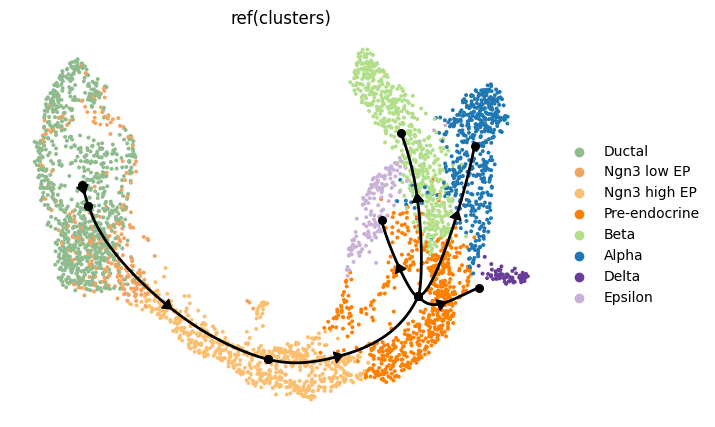

In [2]:
fadata = cafe.data.read_pancreas()
cafe.plot.plot_trajectory(fadata)
fadata

Metacell FateAnnData

In [3]:
# fadata for metacell
adata_metacell = sc.read_h5ad("output/26.06.17-metacell_extract/adata_metacell.h5ad")
fadata_metacell = cafe.data.FateAnnData.from_anndata(adata_metacell)
# cell id mapping dict
with open("output/26.06.17-metacell_extract/cell_id_map.json", 'r') as f:
    cell_id_map = json.load(f)
fadata_metacell.id = f"{fadata.id}_metacell"

# Prior information adding
prior_information = fadata.prior_information.copy()
if "start_cell" in prior_information:
    # start cell id should be converted to metacell id
    start_cell_raw_index = fadata.obs.loc[prior_information['start_cell']]["raw_index"]
    start_cell_mc = cell_id_map[start_cell_raw_index]
    prior_information["start_cell"] = start_cell_mc

fadata_metacell.prior_information = prior_information
prior_information

{'cluster': 'clusters', 'basis': 'X_umap', 'start_cell': 'mc-1'}

## Infer trajectory on metacell anndata

Choice 1: choose specific method

In [4]:
# method_name = "comp1"
# method_name = "palantir"
# method_name = "scvelo"
# method = cafe.method.FateMethod(method_name=method_name)
# method.infer_trajectory(fadata_metacell, parameters={"repreprocess": True})

Choice 2: add trajectory mannually

In [5]:
import pandas as pd

milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

new_model_name = "mannual trajectory"
fadata_metacell.add_trajectory_mannually(
    milestone_network=milestone_network,
    model_name=new_model_name
)

array([[<Axes: title={'center': 'mannual trajectory(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

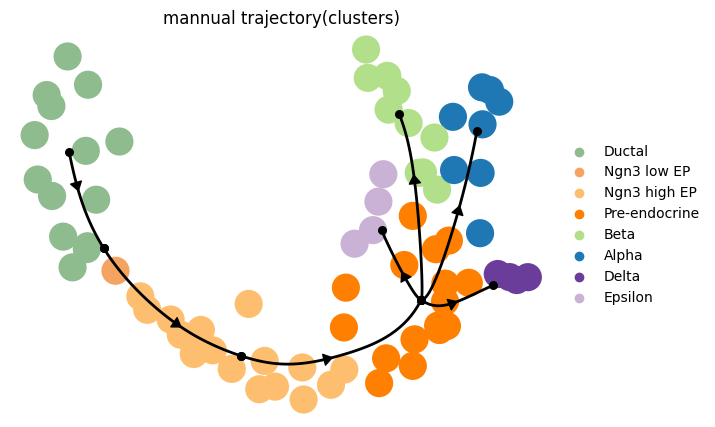

In [6]:
cafe.plot.plot_trajectory(fadata_metacell, model_name=new_model_name)

## Recovery 

INFO     |- Recovered 3,696 progressions for 3,696 cells (wrapper_type='projection').                                                                                                                   


array([[<Axes: title={'center': 'mannual trajectory_recovered(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

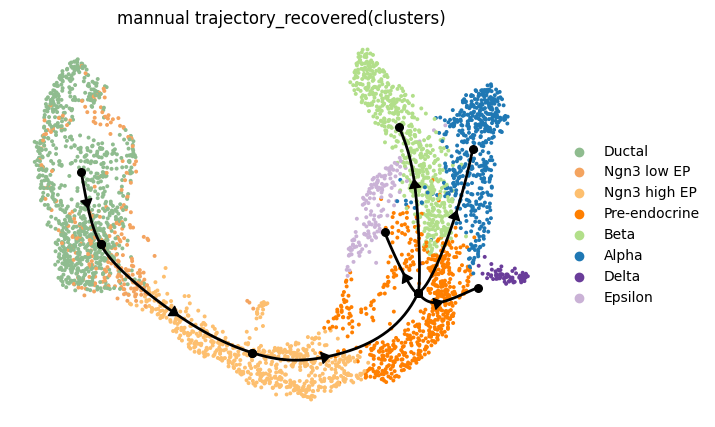

In [7]:
# Recover metacell trajectory → global cell-level trajectory
recovered_model_name = f"{new_model_name}_recovered"
cell_id_dict = fadata.obs.apply(lambda x: cell_id_map[x["raw_index"]], axis=1).to_dict()

# recover metacell
fadata.recovery_metacell(
    fadata_metacell=fadata_metacell,
    cell_id_dict=cell_id_dict,
    model_name=new_model_name,
    recovered_model_name=recovered_model_name,
)

# Plot the recovered trajectory on global cells
cafe.plot.plot_trajectory(fadata, model_name=recovered_model_name, color="clusters")

## Next
